# Discriminative Neuron Clustering Analysis
Analyze discriminative neurons across all BERT layers using t-SNE, PCA, and NMF


## Setup
Import required libraries for dimensionality reduction, clustering, and visualization.


In [1]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, gaussian_kde
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score, accuracy_score, roc_auc_score
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, NMF
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

## Load Data
Load discriminative neurons from all 12 BERT layers. For each layer:
- Read neuron statistics to identify discriminative neurons (those with significant AI/Human discrimination)
- Load activation values for discriminative neurons only
- Track metadata (layer number and neuron index within that layer)

This creates a combined activation matrix of shape `(n_samples, n_discriminative_neurons)` where neurons from all layers are concatenated.


In [2]:
# Load discriminative neurons from all layers
all_layers = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
discriminative_activations = []
neuron_info = []

for layer in all_layers:
    stats_df = pd.read_csv(f'../results/activations/layer_{layer}_neuron_stats.csv')
    discriminative_indices = np.where(stats_df['discriminative'].values)[0]
    layer_activations = np.load(f'../results/activations/layer_{layer}_activations.npy')
    discriminative_activations.append(layer_activations[:, discriminative_indices])
    
    for idx in discriminative_indices:
        neuron_info.append({'layer': layer, 'neuron_idx': idx})
    print(f"Layer {layer}: {len(discriminative_indices)} discriminative neurons")

all_discriminative_activations = np.concatenate(discriminative_activations, axis=1)
neuron_info_df = pd.DataFrame(neuron_info)
labels = np.load('../results/activations/labels.npy')

print(f"\nTotal: {all_discriminative_activations.shape[1]} neurons, {all_discriminative_activations.shape[0]} samples")
print(f"AI: {(labels==1).sum()}, Human: {(labels==0).sum()}")

Layer 1: 128 discriminative neurons
Layer 2: 111 discriminative neurons
Layer 3: 116 discriminative neurons
Layer 4: 83 discriminative neurons
Layer 5: 84 discriminative neurons
Layer 6: 95 discriminative neurons
Layer 7: 84 discriminative neurons
Layer 8: 45 discriminative neurons
Layer 9: 89 discriminative neurons
Layer 10: 164 discriminative neurons
Layer 11: 181 discriminative neurons
Layer 12: 170 discriminative neurons

Total: 1350 neurons, 3000 samples
AI: 1500, Human: 1500


## Topic Validation
**Critical Control**: Verify that each Wikipedia topic appears in only ONE class (AI or Human).

Since our dataset consists of:
- **Human**: Original Wikipedia introductions
- **AI**: ChatGPT-generated text based on the same topics

We need to ensure there's NO topic overlap between classes. If a topic appears in both AI and Human samples, neurons might discriminate based on **topic content** rather than **writing style**.

**Expected result**: Zero overlap → neurons discriminate linguistic style, not topical content.


In [3]:
# TOPIC VALIDATION: Ensure 1000 unique topics, no overlap
print("="*70)
print("TOPIC VALIDATION")
print("="*70)

# Each sample is a different Wikipedia topic
topic_ids = np.arange(len(labels))
ai_topics = set(topic_ids[labels == 1])
human_topics = set(topic_ids[labels == 0])
overlap = ai_topics & human_topics

print(f"\nUnique AI topics: {len(ai_topics)}")
print(f"Unique Human topics: {len(human_topics)}")
print(f"Total unique topics: {len(set(topic_ids))}")
print(f"Topic overlap: {len(overlap)}")

if len(overlap) > 0:
    print(f"⚠️  WARNING: {len(overlap)} topics in both classes - creates confounding!")
else:
    print("✓ No overlap: neurons discriminate STYLE not content")


TOPIC VALIDATION

Unique AI topics: 1500
Unique Human topics: 1500
Total unique topics: 3000
Topic overlap: 0
✓ No overlap: neurons discriminate STYLE not content


## t-SNE Visualization
**Non-linear dimensionality reduction** to visualize discriminative neuron activations in 2D.

t-SNE (t-Distributed Stochastic Neighbor Embedding) preserves local structure and reveals non-linear patterns that PCA might miss. 

**What to look for:**
- Do AI and Human samples form distinct clusters?
- Are there sub-clusters within each class?
- How well separated are the classes?

**Metrics computed:**
- **Separation ratio**: Distance between class centroids / average within-class spread (higher = better)
- **Linear separability**: Can a simple logistic regression separate the classes in t-SNE space?


t-SNE
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 3000 samples in 0.009s...
[t-SNE] Computed neighbors for 3000 samples in 1.594s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3000
[t-SNE] Computed conditional probabilities for sample 2000 / 3000
[t-SNE] Computed conditional probabilities for sample 3000 / 3000
[t-SNE] Mean sigma: 11.192954
[t-SNE] KL divergence after 250 iterations with early exaggeration: 80.483902
[t-SNE] KL divergence after 1000 iterations: 1.700130


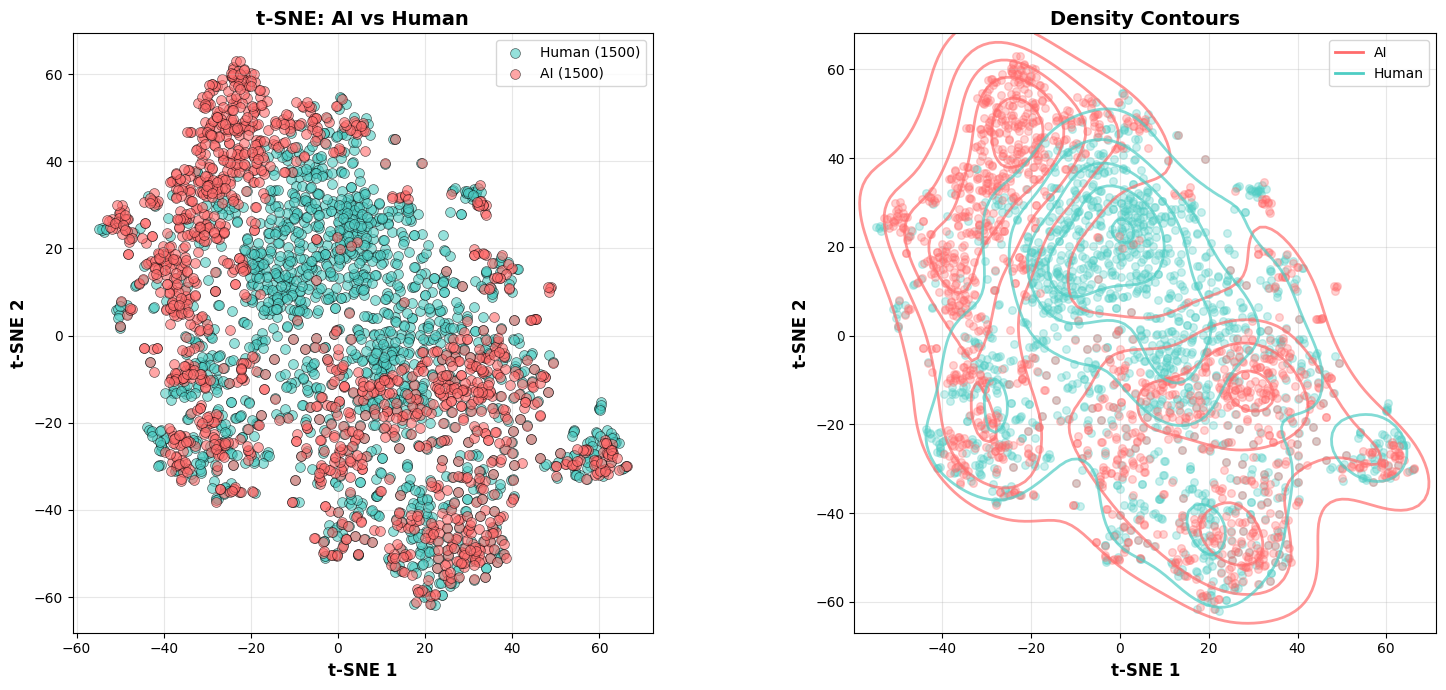


Separation: 0.183 | Acc: 0.572 | AUC: 0.574


In [4]:
# t-SNE Visualization
print("="*70)
print("t-SNE")
print("="*70)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(all_discriminative_activations)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000, verbose=1)
X_tsne = tsne.fit_transform(X_scaled)

ai_mask = labels == 1
human_mask = labels == 0

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter
ax = axes[0]
ax.scatter(X_tsne[human_mask, 0], X_tsne[human_mask, 1], c='#4ecdc4', label=f'Human ({human_mask.sum()})', 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.scatter(X_tsne[ai_mask, 0], X_tsne[ai_mask, 1], c='#ff6b6b', label=f'AI ({ai_mask.sum()})', 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.set_xlabel('t-SNE 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE 2', fontsize=12, fontweight='bold')
ax.set_title('t-SNE: AI vs Human', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.set_aspect('equal')

# Density
ax = axes[1]
kde_ai = gaussian_kde(X_tsne[ai_mask].T)
kde_human = gaussian_kde(X_tsne[human_mask].T)
x_min, x_max = X_tsne[:, 0].min() - 5, X_tsne[:, 0].max() + 5
y_min, y_max = X_tsne[:, 1].min() - 5, X_tsne[:, 1].max() + 5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
positions = np.vstack([xx.ravel(), yy.ravel()])

ax.contour(xx, yy, kde_ai(positions).reshape(xx.shape), levels=5, colors='#ff6b6b', linewidths=2, alpha=0.7)
ax.contour(xx, yy, kde_human(positions).reshape(xx.shape), levels=5, colors='#4ecdc4', linewidths=2, alpha=0.7)
ax.scatter(X_tsne[human_mask, 0], X_tsne[human_mask, 1], c='#4ecdc4', alpha=0.3, s=30)
ax.scatter(X_tsne[ai_mask, 0], X_tsne[ai_mask, 1], c='#ff6b6b', alpha=0.3, s=30)
ax.set_xlabel('t-SNE 1', fontsize=12, fontweight='bold')
ax.set_ylabel('t-SNE 2', fontsize=12, fontweight='bold')
ax.set_title('Density Contours', fontsize=14, fontweight='bold')
ax.legend([Line2D([0], [0], color='#ff6b6b', lw=2), Line2D([0], [0], color='#4ecdc4', lw=2)], 
          ['AI', 'Human'])
ax.grid(alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

# Metrics
cent_ai = X_tsne[ai_mask].mean(axis=0)
cent_human = X_tsne[human_mask].mean(axis=0)
sep_ratio = np.linalg.norm(cent_ai - cent_human) / \
            ((np.linalg.norm(X_tsne[ai_mask] - cent_ai, axis=1).mean() + 
              np.linalg.norm(X_tsne[human_mask] - cent_human, axis=1).mean()) / 2)

lr = LogisticRegression(random_state=42)
lr.fit(X_tsne, labels)
acc = accuracy_score(labels, lr.predict(X_tsne))
auc = roc_auc_score(labels, lr.predict_proba(X_tsne)[:, 1])

print(f"\nSeparation: {sep_ratio:.3f} | Acc: {acc:.3f} | AUC: {auc:.3f}")


## PCA Visualization
**Linear dimensionality reduction** to find the principal components of variation.

PCA finds orthogonal directions that maximize variance. Unlike t-SNE:
- **Deterministic**: Same result every time
- **Fast**: Runs in seconds
- **Interpretable**: PC loadings show which neurons contribute most

**Key insights:**
- **Explained variance**: How much information do PC1 and PC2 capture?
  - High (>50%): Data has strong linear structure
  - Low (<20%): Data is high-dimensional and complex (non-linear methods needed)
- **Top contributors**: Which specific neurons drive the main axis of variation?

**Comparison with t-SNE:** If both show similar separation, the structure is robust. If only t-SNE shows separation, the structure is non-linear.


PCA

Explained: PC1=9.21%, PC2=6.67%, Total=15.88%


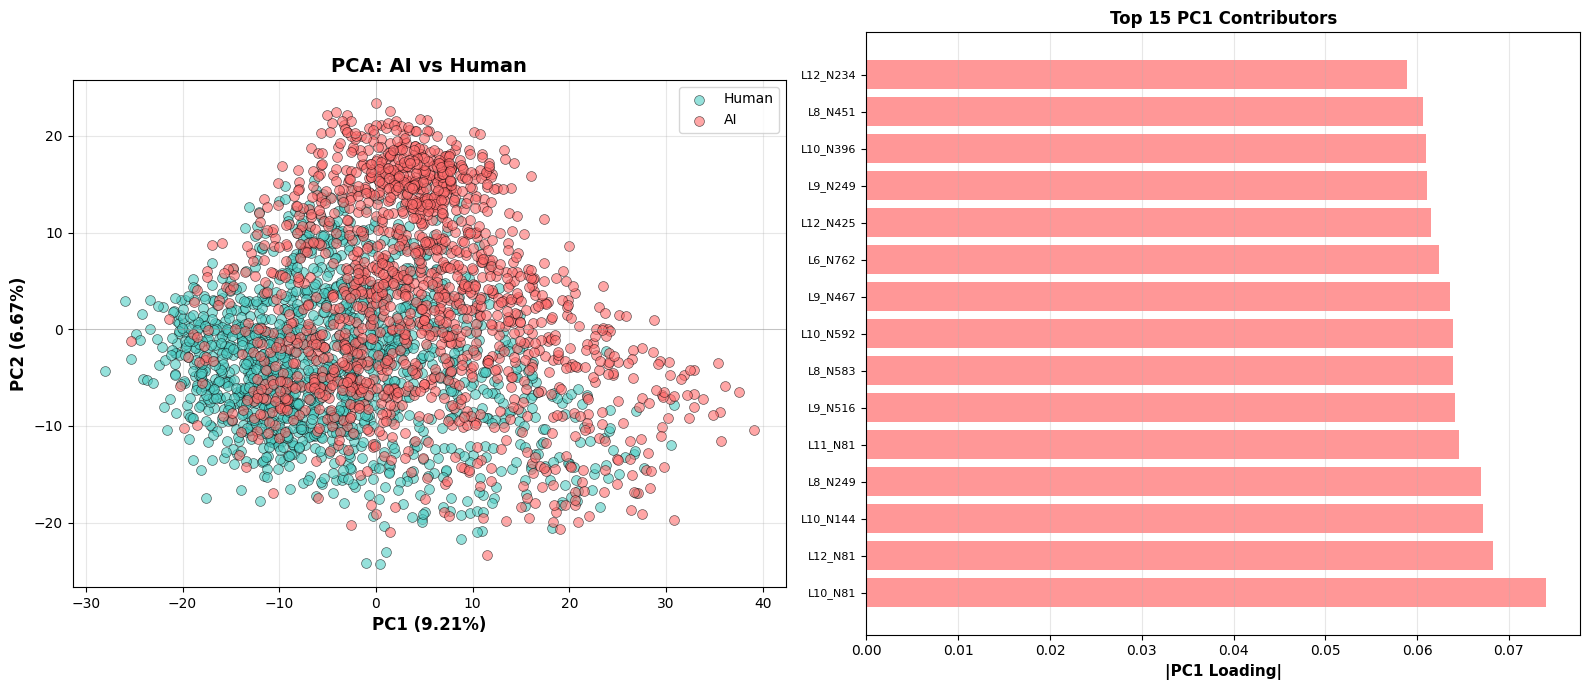


Acc: 0.723 | AUC: 0.818


In [5]:
# PCA Visualization
print("="*70)
print("PCA")
print("="*70)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
exp_var = pca.explained_variance_ratio_

print(f"\nExplained: PC1={exp_var[0]:.2%}, PC2={exp_var[1]:.2%}, Total={exp_var.sum():.2%}")

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatter
ax = axes[0]
ax.scatter(X_pca[human_mask, 0], X_pca[human_mask, 1], c='#4ecdc4', label='Human', 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.scatter(X_pca[ai_mask, 0], X_pca[ai_mask, 1], c='#ff6b6b', label='AI', 
           alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
ax.set_xlabel(f'PC1 ({exp_var[0]:.2%})', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({exp_var[1]:.2%})', fontsize=12, fontweight='bold')
ax.set_title('PCA: AI vs Human', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
ax.axhline(0, color='gray', lw=0.5, alpha=0.5)
ax.axvline(0, color='gray', lw=0.5, alpha=0.5)
ax.set_aspect('equal')

# Top contributors
ax = axes[1]
n_top = 15
pc1_load = np.abs(pca.components_[0])
top_idx = np.argsort(pc1_load)[-n_top:][::-1]
y_pos = np.arange(n_top)
ax.barh(y_pos, pc1_load[top_idx], alpha=0.7, color='#ff6b6b')
ax.set_yticks(y_pos)
ax.set_yticklabels([f"L{neuron_info_df.iloc[i]['layer']}_N{neuron_info_df.iloc[i]['neuron_idx']}" 
                     for i in top_idx], fontsize=8)
ax.set_xlabel('|PC1 Loading|', fontsize=11, fontweight='bold')
ax.set_title(f'Top {n_top} PC1 Contributors', fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

lr_pca = LogisticRegression(random_state=42)
lr_pca.fit(X_pca, labels)
print(f"\nAcc: {accuracy_score(labels, lr_pca.predict(X_pca)):.3f} | AUC: {roc_auc_score(labels, lr_pca.predict_proba(X_pca)[:, 1]):.3f}")


## NMF Clustering
**Non-Negative Matrix Factorization** to discover functional neuron groups.

NMF decomposes the activation matrix into:
- **W matrix** (n_neurons × k): Neuron loadings on k components (soft clustering)
- **H matrix** (k × n_samples): Component activations across samples

**Why NMF?**
- Non-negative, interpretable components (unlike PCA which can have negative values)
- Parts-based representation: neurons can belong to multiple groups
- Reveals functional modules: groups of neurons that co-activate

**Model Selection (k=5 to 10):**
- **Reconstruction error**: How well does NMF approximate the original data? (lower = better fit)
- **Silhouette score**: How well-separated are the clusters? (higher = better clustering)
- **Cluster sizes**: Are clusters balanced or is one dominant?

The "best k" is selected by maximizing silhouette score (clustering quality).


NMF CLUSTERING
k=2: Recon=31.411, Sil=0.480, Sizes=[2242  758]
k=3: Recon=29.952, Sil=0.653, Sizes=[1282    0 1718]
k=4: Recon=28.880, Sil=0.173, Sizes=[ 810   26  381 1783]
k=5: Recon=28.786, Sil=0.398, Sizes=[ 330   58    0    0 2612]
k=6: Recon=29.210, Sil=0.185, Sizes=[ 189    0   72    0  533 2206]
k=7: Recon=28.204, Sil=0.308, Sizes=[  59    0    0  213  478  171 2079]
k=8: Recon=28.237, Sil=0.106, Sizes=[   0    0    0   74    0  249  549 2128]
k=9: Recon=27.451, Sil=0.142, Sizes=[   0    0    0    1    9  163   41  728 2058]
k=10: Recon=27.554, Sil=0.213, Sizes=[   0    0    0    0    0   69   14  470  865 1582]


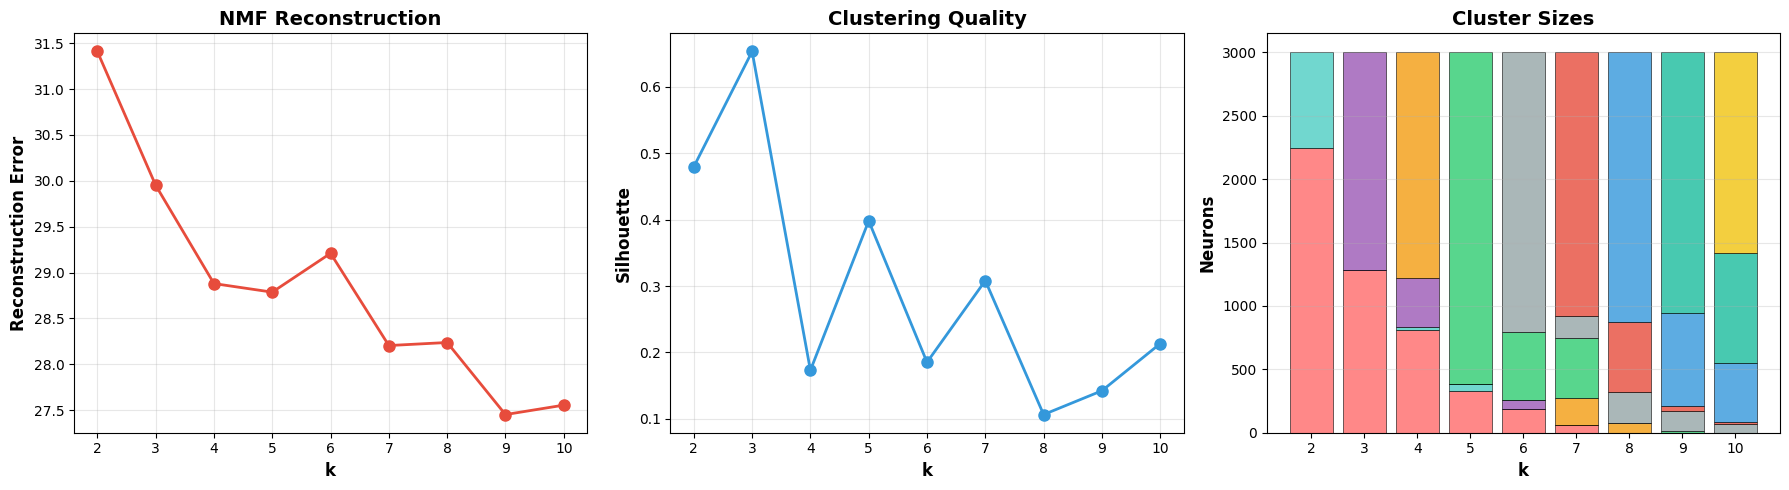


Best k=3


In [7]:
# Non-Negative Matrix Factorization
print("="*70)
print("NMF CLUSTERING")
print("="*70)

scaler_nmf = MinMaxScaler()
act_scaled = scaler_nmf.fit_transform(all_discriminative_activations.T).T

k_values = range(2, 11)
nmf_results = {}

for k in k_values:
    nmf = NMF(n_components=k, init='nndsvda', random_state=42, max_iter=10000)
    W = nmf.fit_transform(act_scaled)
    H = nmf.components_
    clusters = np.argmax(W, axis=1)
    sizes = np.bincount(clusters, minlength=k)
    sil = silhouette_score(W, clusters) if len(np.unique(clusters)) > 1 else -1
    
    nmf_results[k] = {
        'model': nmf, 'W': W, 'H': H, 'clusters': clusters,
        'reconstruction_error': nmf.reconstruction_err_,
        'silhouette': sil, 'cluster_sizes': sizes
    }
    print(f"k={k}: Recon={nmf.reconstruction_err_:.3f}, Sil={sil:.3f}, Sizes={sizes}")

# Model selection
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.plot(k_values, [nmf_results[k]['reconstruction_error'] for k in k_values], 
        'o-', lw=2, ms=8, color='#e74c3c')
ax.set_xlabel('k', fontsize=12, fontweight='bold')
ax.set_ylabel('Reconstruction Error', fontsize=12, fontweight='bold')
ax.set_title('NMF Reconstruction', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_xticks(k_values)

ax = axes[1]
ax.plot(k_values, [nmf_results[k]['silhouette'] for k in k_values], 
        'o-', lw=2, ms=8, color='#3498db')
ax.set_xlabel('k', fontsize=12, fontweight='bold')
ax.set_ylabel('Silhouette', fontsize=12, fontweight='bold')
ax.set_title('Clustering Quality', fontsize=14, fontweight='bold')
ax.grid(alpha=0.3)
ax.set_xticks(k_values)

ax = axes[2]
colors = ['#ff6b6b', '#4ecdc4', '#9b59b6', '#f39c12', '#2ecc71', '#95a5a6', 
          '#e74c3c', '#3498db', '#1abc9c', '#f1c40f']
for i, k in enumerate(k_values):
    bottom = 0
    for j in range(k):
        size = nmf_results[k]['cluster_sizes'][j]
        ax.bar(i, size, width=0.8, bottom=bottom, color=colors[j % len(colors)], 
               alpha=0.8, edgecolor='black', lw=0.5)
        bottom += size
ax.set_xlabel('k', fontsize=12, fontweight='bold')
ax.set_ylabel('Neurons', fontsize=12, fontweight='bold')
ax.set_title('Cluster Sizes', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(k_values)))
ax.set_xticklabels(k_values)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

best_k = k_values[np.argmax([nmf_results[k]['silhouette'] for k in k_values])]
print(f"\nBest k={best_k}")
